In [ ]:
!pip install numpy matplotlib -q

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

def mandelbrot(width, height, cx, cy, zoom, max_iter):
    scale = 1.5 / zoom
    x = np.linspace(cx - scale, cx + scale, width)
    y = np.linspace(cy - scale * height / width, cy + scale * height / width, height)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    escape_iter = np.full(C.shape, max_iter, dtype=float)
    mask = np.ones(C.shape, dtype=bool)  # True = still inside (never escaped)
    for i in range(max_iter):
        Z[mask] = Z[mask] ** 2 + C[mask]
        escaped_now = mask & (np.abs(Z) > 2)
        with np.errstate(invalid="ignore"):
            escape_iter[escaped_now] = i + 1 - np.log(np.log(np.abs(Z[escaped_now]))) / np.log(2)
        mask &= ~escaped_now
        if not mask.any():
            break
    return escape_iter, mask

# Cyclic vibrant palette: orange -> white -> cyan -> deep blue -> loops back to orange
colors = ["#ff8a00", "#ffe08a", "#ffffff", "#7fdcff", "#1c4fa1", "#0a1a4d", "#ff8a00"]
cyclic_cmap = LinearSegmentedColormap.from_list("cyclic_vibrant", colors, N=512)

W, H = 1400, 1400
cx, cy, zoom, max_iter = -0.7453, 0.1127, 300, 600   # a "seahorse valley" spiral spot
escape_iter, interior = mandelbrot(W, H, cx, cy, zoom, max_iter)

freq = 0.06  # ring density — raise for more bands, lower for fewer/bolder ones
normalized = (escape_iter * freq) % 1.0

rgba = cyclic_cmap(normalized)
rgba[interior] = [0, 0, 0, 1]  # force never-escaped points to solid black

fig, ax = plt.subplots(figsize=(10, 10), dpi=150)
ax.imshow(rgba, interpolation="bilinear")
ax.set_axis_off()
plt.subplots_adjust(left=0, right=1, top=1, bottom=0)
plt.savefig("mandelbrot_vibrant_shirt.png", bbox_inches="tight", pad_inches=0)
plt.show()

In [ ]:
"""
Simple Colorful Mandelbrot Set Fractal
---------------------------------------
Pure Python (NumPy + Matplotlib). No shirt, just a clean, vibrant
Mandelbrot fractal image.

Run:  python3 mandelbrot.py
Output: mandelbrot.png
"""

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap


def mandelbrot(size, x_min, x_max, y_min, y_max, max_iter=300):
    x = np.linspace(x_min, x_max, size)
    y = np.linspace(y_min, y_max, size)
    X, Y = np.meshgrid(x, y)
    C = X + 1j * Y
    Z = np.zeros_like(C)
    div_time = np.full(C.shape, max_iter, dtype=float)

    mask = np.ones(C.shape, dtype=bool)
    for i in range(max_iter):
        Z[mask] = Z[mask] ** 2 + C[mask]
        escaped = np.abs(Z) > 2
        newly_escaped = escaped & mask
        div_time[newly_escaped] = i + 1 - np.log(np.log(np.abs(Z[newly_escaped]))) / np.log(2)
        mask &= ~escaped
    return div_time


def make_design(save_path="mandelbrot.png"):
    size = 1200
    max_iter = 300
    div_time = mandelbrot(size, -2.0, 0.6, -1.3, 1.3, max_iter=max_iter)

    # A hot, highly saturated cyclic palette -> lots of repeating vibrant
    # color bands across the whole image (not just at the edge).
    vivid_colors = [
        "#000000", "#ff00e6", "#7d00ff", "#0033ff", "#00e5ff",
        "#00ff5e", "#c8ff00", "#ffb300", "#ff2b00", "#ff00a6",
        "#000000",
    ]
    vivid_cmap = LinearSegmentedColormap.from_list("vivid", vivid_colors, N=1024)

    # Cycle the smooth escape values through the palette several times so
    # color repeats in rings, instead of one slow gradient end to end.
    cycles = 6
    shaded = (div_time % (max_iter / cycles)) / (max_iter / cycles)
    shaded[div_time >= max_iter - 1] = 0  # interior stays black

    fig, ax = plt.subplots(figsize=(8, 8), dpi=200)
    ax.imshow(shaded, cmap=vivid_cmap, origin="lower")
    ax.axis("off")

    plt.tight_layout(pad=0)
    plt.savefig(save_path, facecolor="black", bbox_inches="tight", pad_inches=0)
    print(f"Saved: {save_path}")


if __name__ == "__main__":
    make_design("/mnt/user-data/outputs/mandelbrot.png")

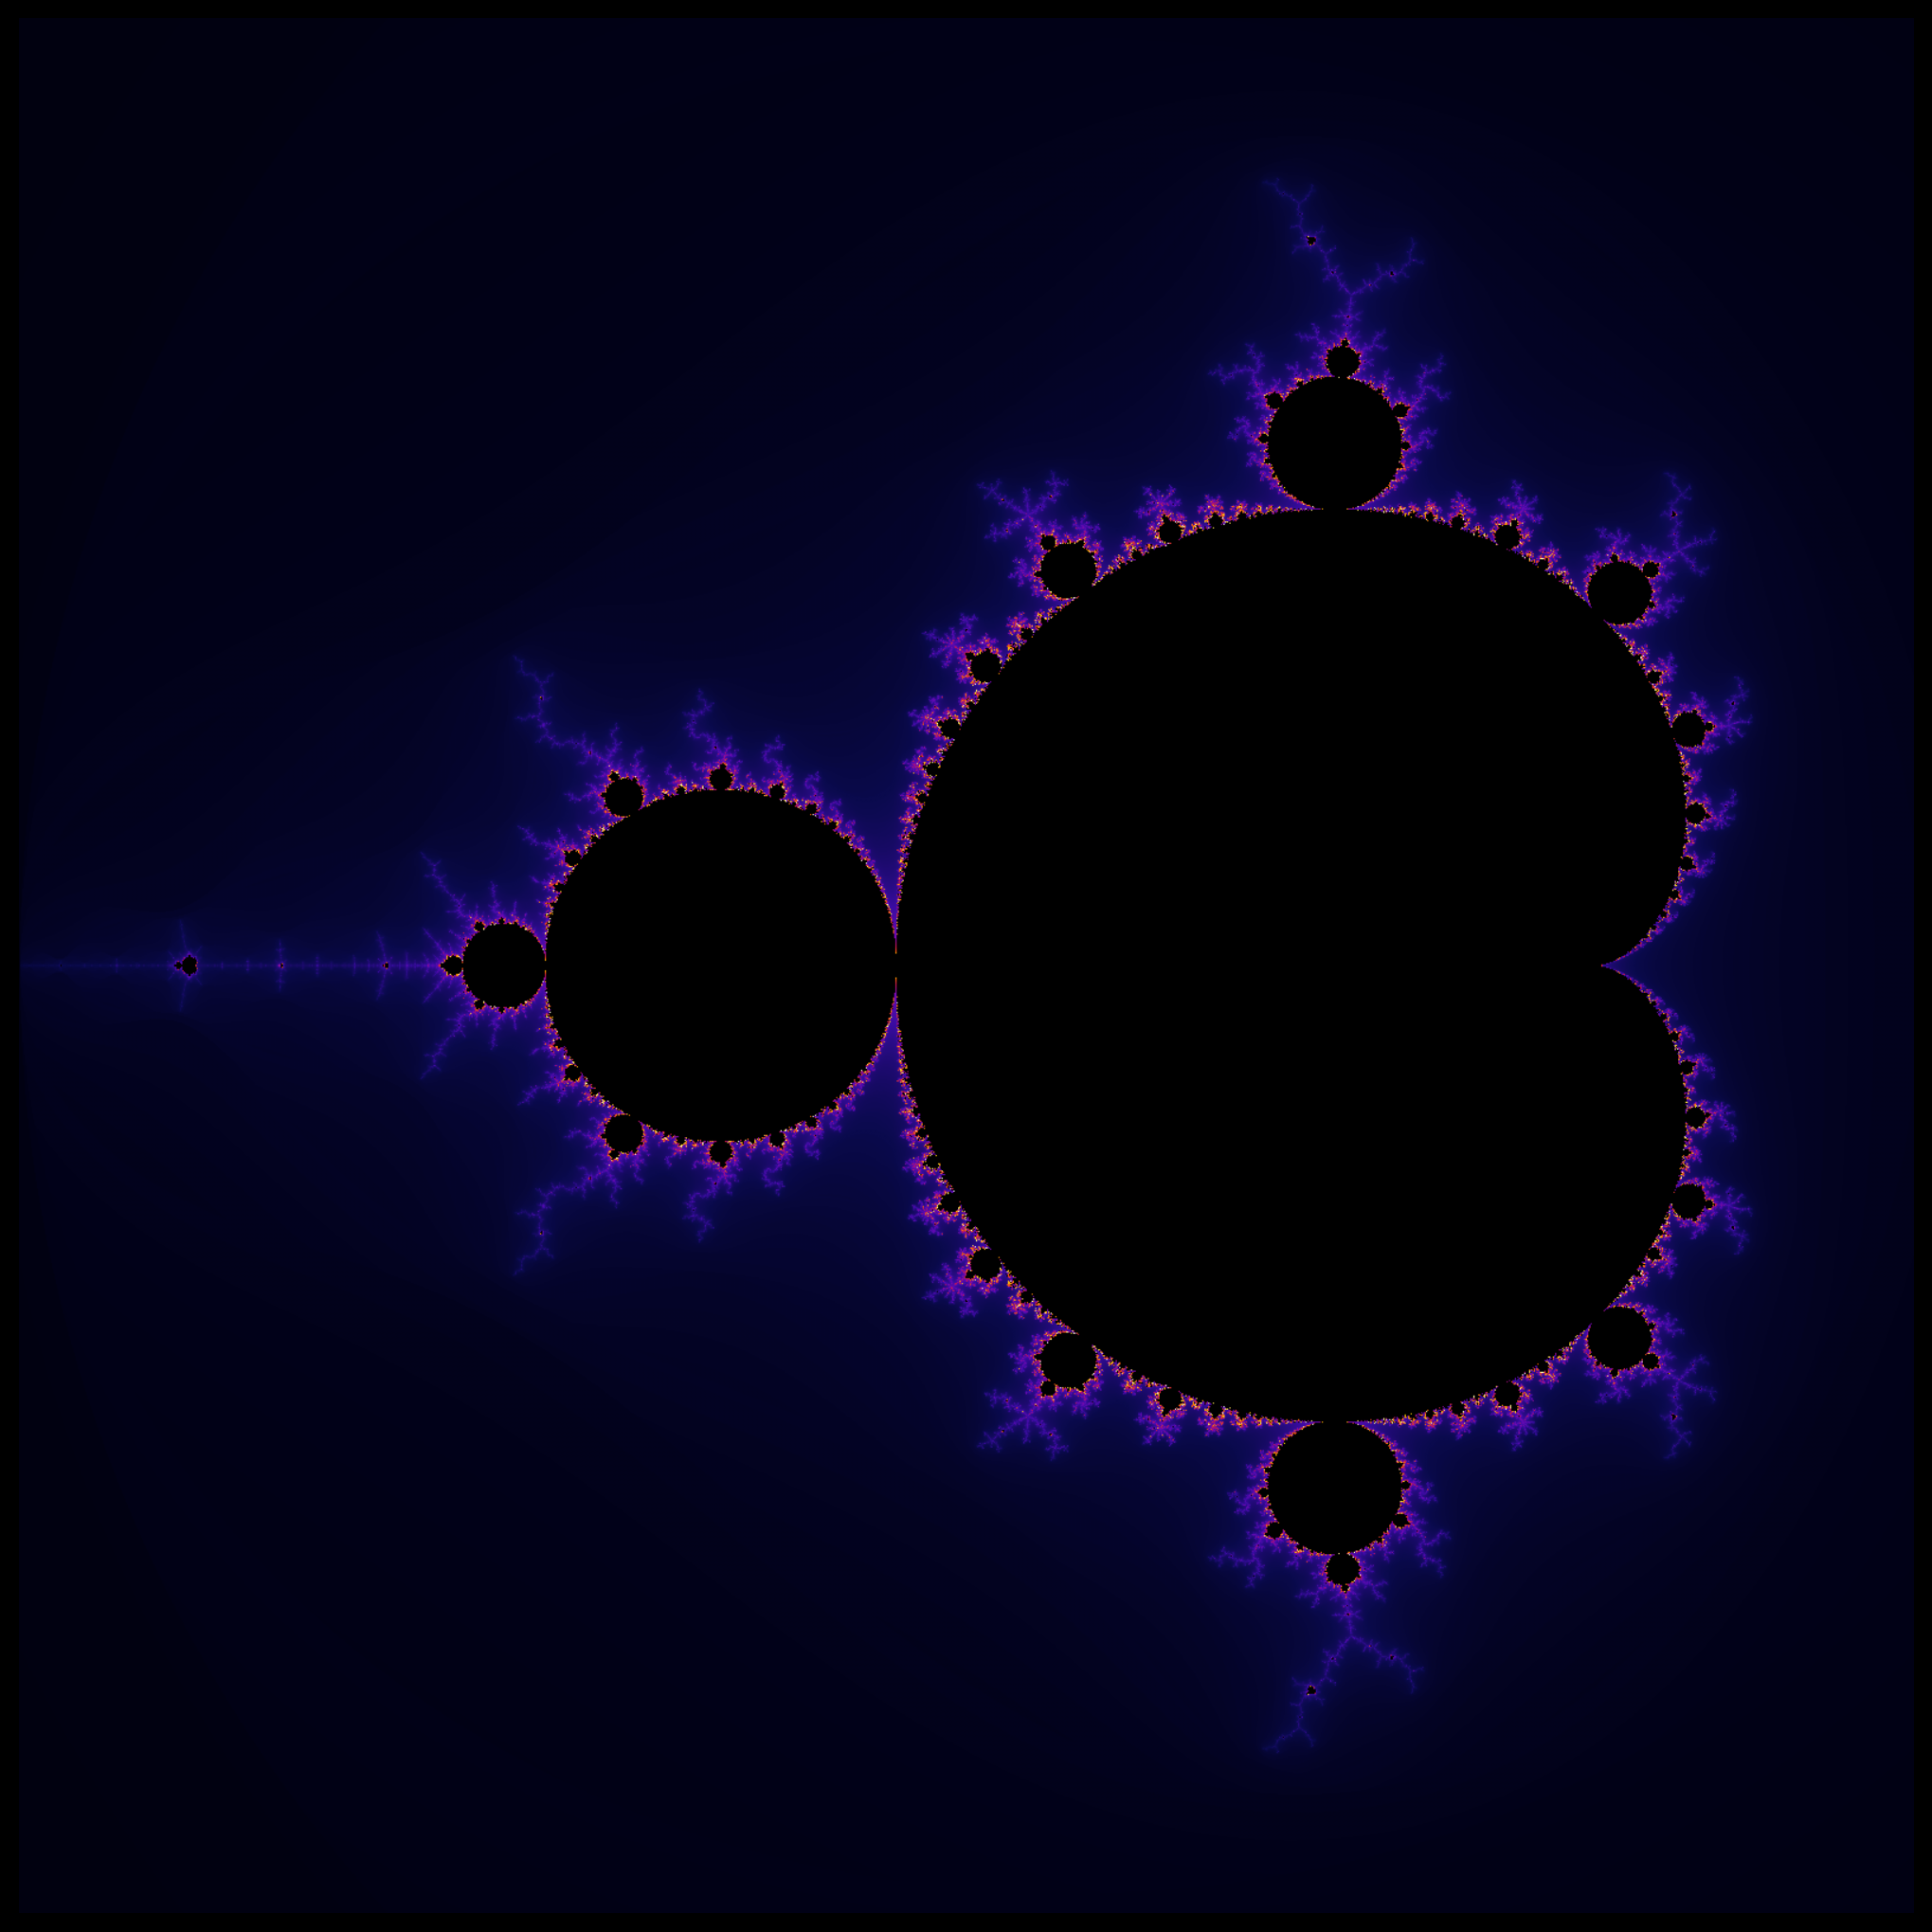

Saved as mandelbrot_black_bg.png (check the Colab file browser on the left, or it will download automatically below)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# High-res grid
width, height = 1600, 1600
max_iter = 300

x = np.linspace(-2.0, 0.7, width)
y = np.linspace(-1.35, 1.35, height)
X, Y = np.meshgrid(x, y)
C = X + 1j * Y
Z = np.zeros_like(C)
div_time = np.zeros(C.shape, dtype=float)
mask = np.ones(C.shape, dtype=bool)

for i in range(max_iter):
    Z[mask] = Z[mask] ** 2 + C[mask]
    escaped = np.abs(Z) > 2
    newly_escaped = escaped & mask
    # smooth coloring using log-based escape time
    div_time[newly_escaped] = i + 1 - np.log(np.log(np.abs(Z[newly_escaped]) + 1e-10)) / np.log(2)
    mask[newly_escaped] = False

div_time[mask] = 0  # points that never escaped -> pure black (interior)

# Custom colormap: black -> deep blue -> purple -> magenta -> orange -> gold -> white
colors = [
    (0.00, "#000000"),
    (0.10, "#02021a"),
    (0.20, "#0a0a4d"),
    (0.35, "#3a0ca3"),
    (0.50, "#7209b7"),
    (0.62, "#c9184a"),
    (0.75, "#ff6d00"),
    (0.88, "#ffd60a"),
    (1.00, "#ffffff"),
]
cmap = LinearSegmentedColormap.from_list("fire_purple", colors)
cmap.set_bad(color="black")

fig, ax = plt.subplots(figsize=(10, 10), dpi=200)
fig.patch.set_facecolor("black")
ax.set_facecolor("black")

norm_div = np.sqrt(div_time / div_time.max())  # sqrt to boost mid-tone detail
im = ax.imshow(norm_div, extent=[x.min(), x.max(), y.min(), y.max()],
               cmap=cmap, origin="lower", interpolation="bilinear")

ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_visible(False)

plt.tight_layout(pad=0)
plt.savefig("mandelbrot_black_bg.png",
            facecolor="black", bbox_inches="tight", pad_inches=0)
plt.show()
print("Saved as mandelbrot_black_bg.png (check the Colab file browser on the left, or it will download automatically below)")

# Optional: auto-download the file in Google Colab
try:
    from google.colab import files
    files.download("mandelbrot_black_bg.png")
except ImportError:
    pass  # not running in Colab